In [9]:
import numpy
from matplotlib import pyplot

In [158]:
def model_spins(spin_count: int, T: float, step_count: int, B: float = 1, initial_towards = False) -> tuple[numpy.ndarray, numpy.ndarray]:
    spins = (1 if initial_towards else -1) * numpy.ones(spin_count)

    def magniticity():
        return numpy.sum(spins)

    def energy():
        return -B * magniticity()

    def enthropy():
        pluses = numpy.sum(spins == 1)
        minuses = numpy.sum(spins == -1)

        if pluses == 0 or minuses == 0:
            return 0
        return pluses * -numpy.log(pluses / len(spins)) + minuses * -numpy.log(minuses / len(spins))
    
    magniticities, enthropies = [], []
    for _ in range(step_count):
        magniticities.append(magniticity())
        enthropies.append(enthropy())

        current_energy = energy()

        switched = numpy.random.randint(0, len(spins))
        spins[switched] = -spins[switched]

        deltaEnergy = energy() - current_energy
        if deltaEnergy > 0 and numpy.random.random() > numpy.exp(-deltaEnergy / T):
            spins[switched] = -spins[switched]
    
    return numpy.array(magniticities), numpy.array(enthropies)

In [159]:
M, S = model_spins(1000, 273, 10000)

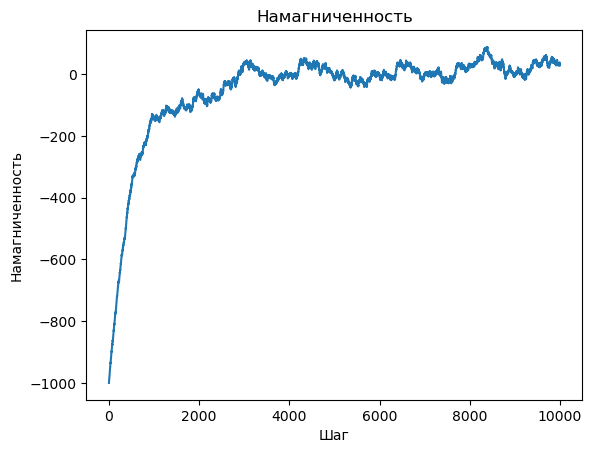

In [160]:
pyplot.plot(numpy.arange(len(M)), M)
pyplot.xlabel('Шаг')
pyplot.ylabel('Намагниченность')
pyplot.title('Намагниченность')
pyplot.show()

[  0.           7.90725511  14.42721486 ... 692.63509314 692.69711304
 692.75512932]


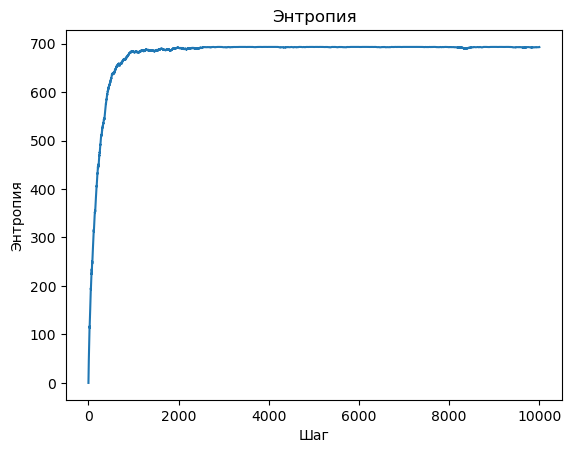

In [161]:
print(S)
pyplot.plot(numpy.arange(len(S)), S)
pyplot.xlabel('Шаг')
pyplot.ylabel('Энтропия')
pyplot.title('Энтропия')
pyplot.show()

In [164]:
def analyze_average_magniticity(spin_count: int, Ts: numpy.ndarray, step_count: int,
                                B: float = 1, initial_towards = False) -> tuple[numpy.ndarray, numpy.ndarray]:
    average_mangniticities = []
    average_enthropies = []
    for T in Ts:
        magniticities, enthropies = model_spins(spin_count, T, step_count, B, initial_towards)
        average_mangniticities.append(numpy.average(magniticities[-step_count // 2:]))
        average_enthropies.append(numpy.average(enthropies[-step_count // 2:]))
    return numpy.array(average_mangniticities), numpy.array(average_enthropies)

In [165]:
# Ts = numpy.concatenate([numpy.arange(1, 100), numpy.arange(100, 1000, 10)])
Ts = numpy.arange(1, 100)
Ms, Ses = analyze_average_magniticity(1000, Ts, 10000)

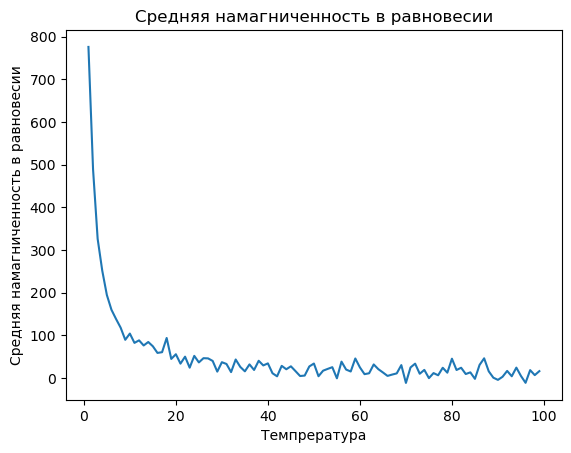

In [166]:
pyplot.plot(Ts, Ms)
pyplot.xlabel('Темпрература')
pyplot.ylabel('Средняя намагниченность в равновесии')
pyplot.title('Средняя намагниченность в равновесии')
pyplot.show()

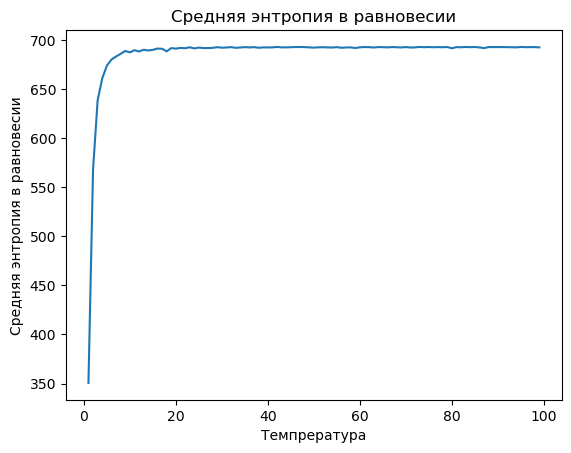

In [168]:
pyplot.plot(Ts, Ses)
pyplot.xlabel('Темпрература')
pyplot.ylabel('Средняя энтропия в равновесии')
pyplot.title('Средняя энтропия в равновесии')
pyplot.show()